# Parameter-Efficient Fine-Tuning (PEFT)

## What is PEFT?
- Fine-tunes pretrained LLMs using only a small subset of parameters.
- Preserves the model’s structure and pretraining knowledge.
- Reduces training cost, time, and memory footprint.

## How It Works
- Most parameters are frozen.
- Adds trainable components (e.g., adapters).
- May use gradient checkpointing for memory efficiency.

## Why Use PEFT?
- Ideal for transfer learning.
- Avoids catastrophic forgetting and overfitting.
- Reduces storage and computational demands.

## PEFT vs Full Fine-Tuning

| Feature                 | Full Fine-Tuning             | PEFT                              |
|------------------------|------------------------------|------------------------------------|
| Parameters Updated     | All                          | Few (e.g., adapters)              |
| Compute/Cost           | High                         | Low                               |
| Time to Value          | Slow                         | Fast                              |
| Model Size             | Large                        | Compact                           |
| Risk of Overfitting    | Higher                       | Lower                             |

## Benefits
- Increased efficiency and speed
- Lower storage and data requirements
- Accessible to more teams
- Greater flexibility for specific use cases

## PEFT Techniques
- Adapters: Add trainable modules to each layer
- LoRA: Low-rank matrix adaptation
- QLoRA: Quantized LoRA (4-bit weights)
- Prefix-Tuning: Task-specific prefix vectors
- Prompt-Tuning: Hard (Humman Written) or soft (Learned Vector) prompt injection 

# LoRA: Low-Rank Adaptation for Fine-Tuning Large Models

---

## Why Not Traditional Fine-Tuning?

- Traditional fine-tuning updates all weights (W) in a pretrained model.
- For a weight matrix of size `d × d`, this results in `d²` trainable parameters.
- Consequences:
  - High memory usage
  - Long training time
  - Significant compute cost
- Not practical for very large models.

---

## What Is LoRA?

LoRA (Low-Rank Adaptation) addresses the inefficiency by:

- Keeping the pretrained weights `W` frozen.
- Training a low-rank update `ΔW` instead of the full matrix.

LoRA represents `ΔW` as the product of two smaller matrices `A` and `B`:

\[
W' = W + BA
\]

Where:
- `B` has shape `(d × r)`
- `A` has shape `(r × d)`
- `r << d`, meaning far fewer parameters

---

## Intrinsic Rank Hypothesis

- The hypothesis states that meaningful changes to model weights can be captured in a lower-dimensional space.
- Only a small number of directions in parameter space are needed to adapt to new tasks.
- LoRA leverages this by using a low-rank approximation.

---

## Traditional Fine-Tuning
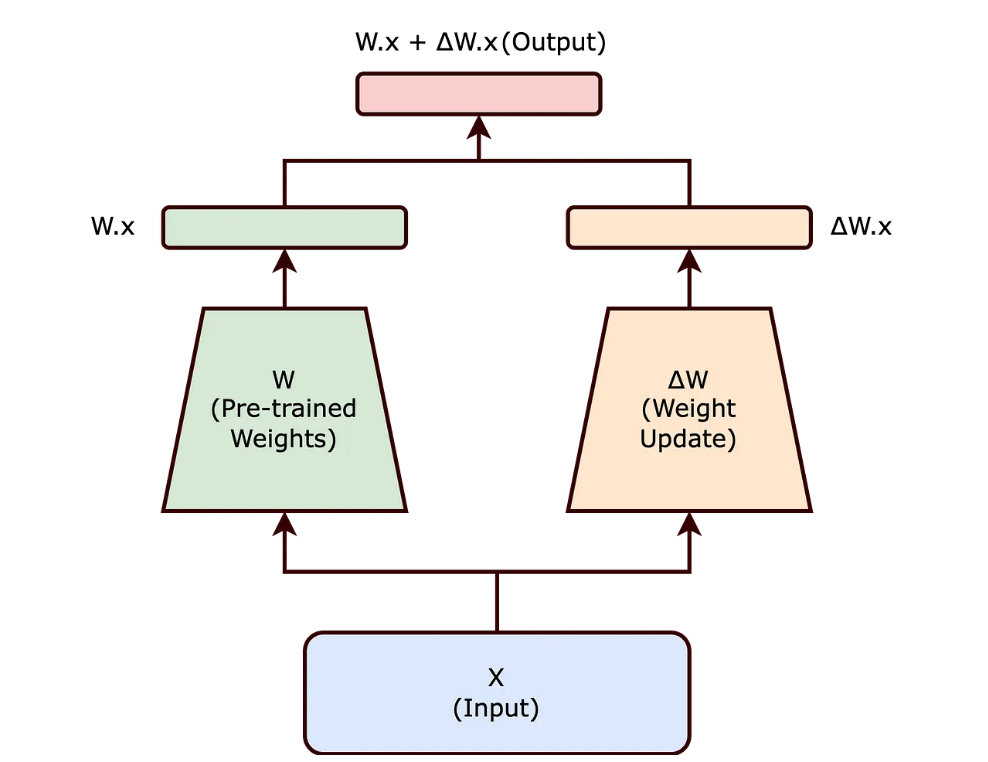

## LoRA
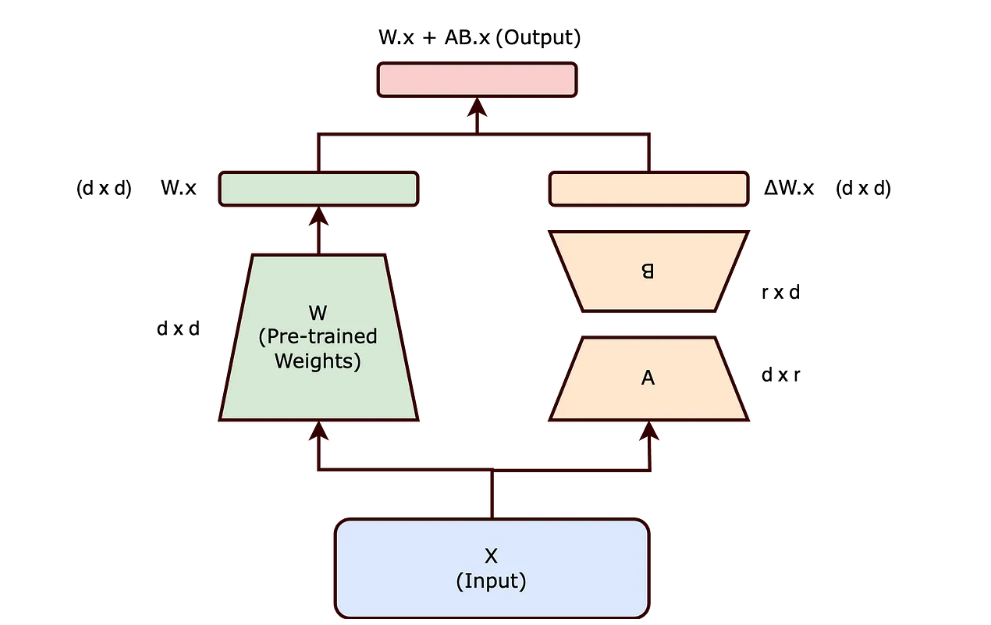

## Efficiency of LoRA

| Method              | Trainable Parameters        |
|---------------------|-----------------------------|
| Traditional Fine-Tuning | `d × d` = `d²`           |
| LoRA                   | `d × r + r × d` = `2dr`   |

Example:  
If `d = 1000` and `r = 8` → LoRA trains only `16,000` parameters instead of `1,000,000`.

---

## Benefits of LoRA

- **Reduced memory footprint**: Less memory required due to fewer trainable parameters.
- **Faster training and adaptation**: Training is faster with fewer computations.
- **Works on smaller hardware**: Fine-tuning is possible on low-resource GPUs or CPUs.
- **Scalable**: Suitable for very large models without large resource costs.
- **General applicability**: Though demonstrated in NLP, the approach is applicable to other domains.

---

## Low Rank Can Still Be Effective

- The rank `r` of matrices `A` and `B` can be surprisingly low.
- In some experiments, even `r = 1` yields effective results.
- This shows that significant adaptation can be achieved with minimal parameter changes.

---

## Conclusion

LoRA offers an efficient way to adapt large pretrained models:

- It avoids retraining all parameters.
- It introduces low-rank matrices to approximate the necessary changes.
- This leads to significant reductions in compute, memory, and time.
- LoRA makes fine-tuning large models feasible and accessible for a wide range of users and use cases.

# PPO, GRPO, and DPO — Simple Analogies

## Overview
These are methods used to train large language models efficiently. Let's understand them using simple baking analogies.
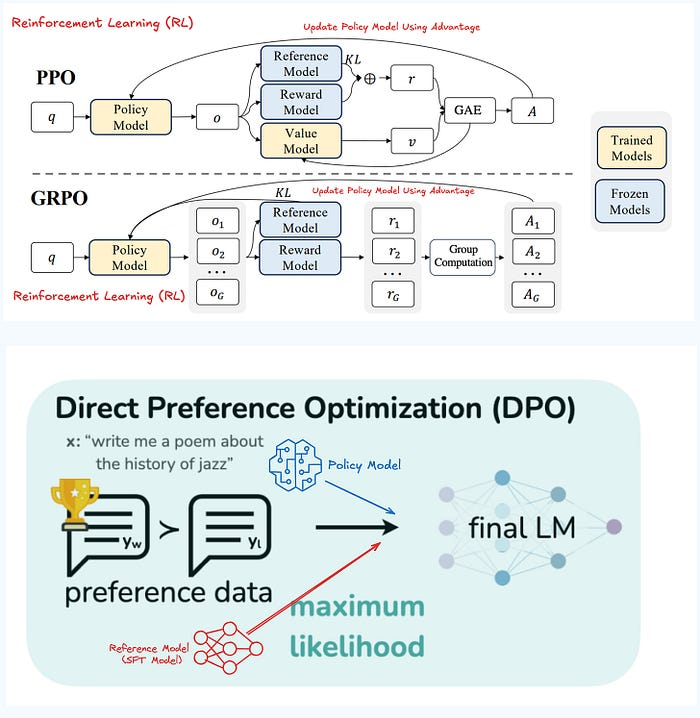
---

## Key Terms (Baking Analogy)
- **Policy Model**: Contestant who bakes cakes (generates answers).
- **Model Parameters**: Baking strategies (how the cake is made).
- **Output**: The cake (model output).
- **Reward Model**: Judge who scores the cake.
- **Value Function**: Prophet who predicts long-term success.
- **Reference Model**: Classic recipe to follow.
- **Preference Data**: Audience votes for the best cake.
- **KL Divergence & BCE Loss**: Rules to stay close to the classic recipe.

---

## PPO – Baking Competition with Judges
- Each contestant bakes a cake based on the classic recipe.
- Judges (reward model) score the cakes.
- A prophet (value function) predicts the long-term success of the contestant.
- Contestants update their baking strategy (model) based on the score.
- **Important**: Strategy changes are small to avoid sudden bad results.
- **Cost**: Expensive – judges and prophets needed for every round.

---

## GRPO – Baking Party with Peer Reviews
- Students bake cakes and compare with each other in groups.
- Judges still score the cakes.
- No prophet is used.
- Students learn by comparing results within the group.
- **Cost**: Cheaper than PPO, but still needs judges.
- **Limitation**: Quality of scoring may vary across groups.

---

## DPO – Baking Show with Audience Voting
- Each contestant bakes two cakes.
- The audience votes for their favorite.
- No judges or prophets needed.
- Recipes are updated to match audience preference while keeping the original style.
- **Advantage**: Much cheaper and faster.
- **Limitation**: Needs good-quality audience votes (preference data).
- **Still needs**: A classic recipe (reference model) to guide training.

---

## Comparison Summary

| Method | Needs Reward Model | Needs Value Function | Uses Preference Data | Cost | Analogy |
|--------|---------------------|-----------------------|-----------------------|------|---------|
| PPO    | ✅ Yes              | ✅ Yes                | ❌ No                 | High | Judge-based baking contest |
| GRPO   | ✅ Yes              | ❌ No                 | Indirectly         | Medium | Peer-reviewed baking party |
| DPO    | ❌ No               | ❌ No                 | ✅ Yes                | Low  | Audience-voted baking show |

---

## Final Notes
- **PPO**: Accurate but costly.
- **GRPO**: Simpler, no value function.
- **DPO**: Easiest and cheapest, but depends on preference quality.